# 4 Лабораторная работа


**Тема**: Решающие деревья и ансамблеввые методы.

**Постановка**: Подготовить датасет с информацией о клиентах банка к обучению деревом решений, разным ансамблевым методам. Оценить влияние гиперпарметров для рассматриваемых методов решений.

**Цель**: Получить практичные навыки применения ансамблирования.

## Загрузка данных и знакомство с ними.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

import pandas as pd

### Прочитаем табличку для 4 лабы
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/4 лаба/credit_scoring.csv')

data.head(20)

,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
0,0,0.496289,49.1,13,0,0.0,2,0,5298.360639,0.387028,0
1,1,0.433567,48.0,9,2,2.0,1,0,6008.056256,0.234679,0
2,2,2206.731199,55.5,21,1,NaN,1,0,NaN,0.348227,0
3,3,886.132793,55.3,3,0,0.0,0,0,NaN,0.971930,0
4,4,0.000000,52.3,1,0,0.0,0,0,2504.613105,1.004350,0
5,5,0.121965,73.5,18,1,1.0,0,0,15634.752299,0.004951,0
6,6,0.461193,71.3,9,0,0.0,0,0,3562.767475,0.039618,0
7,7,2.624982,46.3,6,0,0.0,0,0,2205.386980,0.846364,0
8,8,0.074518,28.1,10,0,0.0,0,0,5021.722284,0.048213,0
9,9,0.266679,31.3,6,0,0.0,0,0,4005.890242,0.366262,0


In [3]:
### Какие типы данных и их формат
data.dtypes

,0
client_id,int64
DIR,float64
Age,float64
NumLoans,int64
NumRealEstateLoans,int64
NumDependents,float64
Num30-59Delinquencies,int64
Num60-89Delinquencies,int64
Income,float64
BalanceToCreditLimit,float64


**Описание колонок**:
<dd> client_id —  ID клиента (неотрицательное целое число) </dd>
<dd> DIR — Debt-to-income Ratio (вещественный) </dd>
<dd> Age — возраст (вещественный) </dd>
<dd> NumLoans — число заемов и кредитных линий </dd>
<dd> NumRealEstateLoans — число ипотек и заемов, связанных с недвижимостью (натуральное число) </dd>
<dd> NumDependents — число членов семьи, которых содержит клиент, исключая самого клиента (натуральное число) </dd>
<dd> Num30-59Delinquencies	— число просрочек выплат по кредиту от 30 до 59 дней (натуральное число) </dd>
<dd> Num60-89Delinquencies	 — число просрочек выплат по кредиту от 60 до 89 дней (натуральное число) </dd>
<dd> Income — месячный доход (вещественный) </dd>
<dd> BalanceToCreditLimit — отношение баланса на кредитной карте к лимту по кредиту (вещественный) </dd>
<dd> Delinquent90 — Таргет, были ли просрочки выплат по кредиту более 90 дней (бинарный) </dd>


</dl>

In [4]:
### Проверка на дубликаты
if data.duplicated().sum() == 0:
  print('ДУБЛИКАТОВ НЕТ')

ДУБЛИКАТОВ НЕТ


In [5]:
print(f'Всего колонок: {data.shape[1]}')
print(f'Всего данных (строк): {len(data)}')

Всего колонок: 11
Всего данных (строк): 75000


In [6]:
print(f"уник. значения id клиентов: {data['client_id'].nunique()}")
print(f"ставим id client в качестве индекса")
data.set_index('client_id', inplace=True)
data.head()

уник. значения id клиентов: 75000
ставим id client в качестве индекса


,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
client_id,,,,,,,,,,
0,0.496289,49.1,13,0,0.0,2,0,5298.360639,0.387028,0
1,0.433567,48.0,9,2,2.0,1,0,6008.056256,0.234679,0
2,2206.731199,55.5,21,1,NaN,1,0,NaN,0.348227,0
3,886.132793,55.3,3,0,0.0,0,0,NaN,0.971930,0
4,0.000000,52.3,1,0,0.0,0,0,2504.613105,1.004350,0


In [7]:
### посмотрим на стат. характеристики числовых колонок
data.describe()


,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
count,75000.000000,75000.000000,75000.00000,75000.000000,73084.000000,75000.000000,75000.000000,6.015300e+04,75000.000000,75000.000000
mean,353.260293,52.595605,8.44976,1.016693,0.755966,0.428320,0.248000,6.740059e+03,6.276196,0.066840
std,2117.237432,14.869729,5.15644,1.124019,1.108119,4.276439,4.239486,1.422875e+04,267.743321,0.249746
min,0.000000,21.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.176022,41.300000,5.00000,0.000000,0.000000,0.000000,0.000000,3.421354e+03,0.029703,0.000000
50%,0.366848,52.200000,8.00000,1.000000,0.000000,0.000000,0.000000,5.424552e+03,0.153720,0.000000
75%,0.862650,63.100000,11.00000,2.000000,1.000000,0.000000,0.000000,8.291518e+03,0.560638,0.000000
max,332600.272820,109.800000,56.00000,32.000000,20.000000,98.000000,98.000000,1.805573e+06,50873.874533,1.000000


По первому впечатлению:
Пропуски будут у колонок дохода и числа иждивенцов. Все колонки не отрицательные. Выбросы будут много где.

In [8]:
### проверим количество пропусков в каждой из колонок, а также число их уникальных значений
missing_values = data.isna().sum()
if missing_values.sum() > 0:
    print('Есть пропуски:')
    columns_with_missing = missing_values[missing_values > 0]
    print(columns_with_missing)

    print('\nКоличество уникальных значений для колонок с пропусками:')
    for col in columns_with_missing.index:
        unique_count = data[col].nunique()
        print(f'{col}: {unique_count} уникальных значений')

    print('\nНет пропусков у колонок:')
    columns_without_missing = missing_values[missing_values == 0].index.tolist()
    print(columns_without_missing)
else:
    print('Пропусков нет')

print(f'\nВсего строк: {data.shape[0]}')

Есть пропуски:
NumDependents     1916
Income           14847
dtype: int64

Количество уникальных значений для колонок с пропусками:
NumDependents: 13 уникальных значений
Income: 59346 уникальных значений

Нет пропусков у колонок:
['DIR', 'Age', 'NumLoans', 'NumRealEstateLoans', 'Num30-59Delinquencies', 'Num60-89Delinquencies', 'BalanceToCreditLimit', 'Delinquent90']

Всего строк: 75000


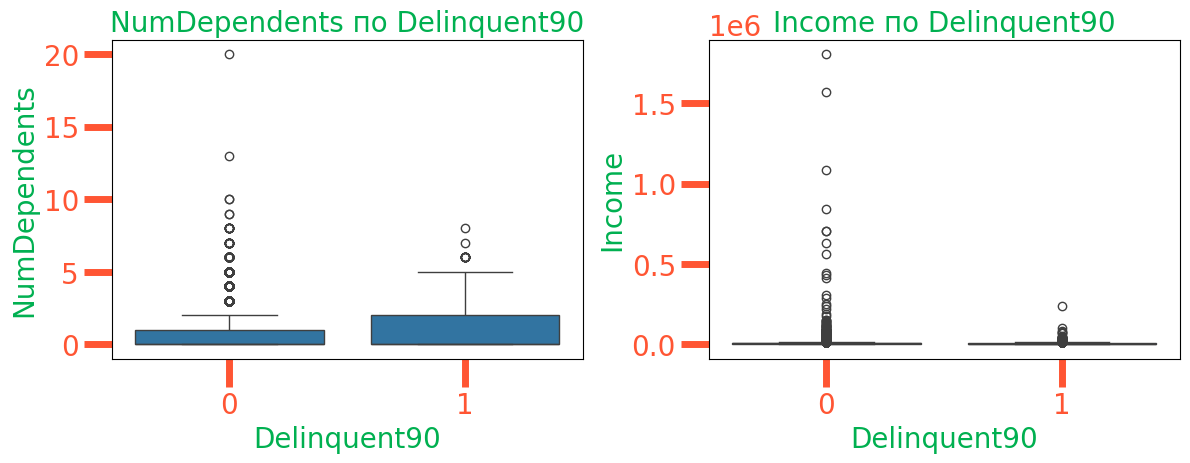

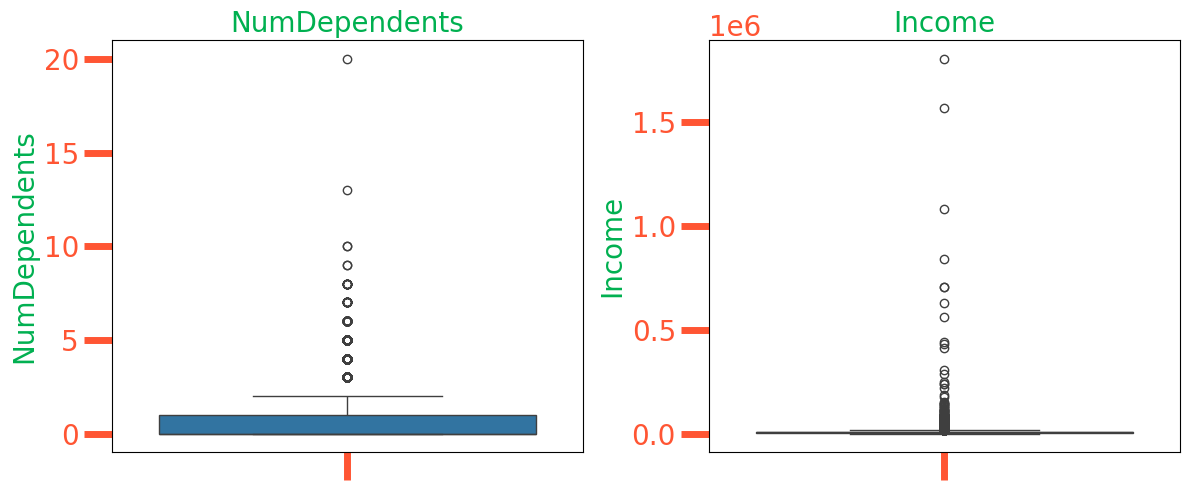

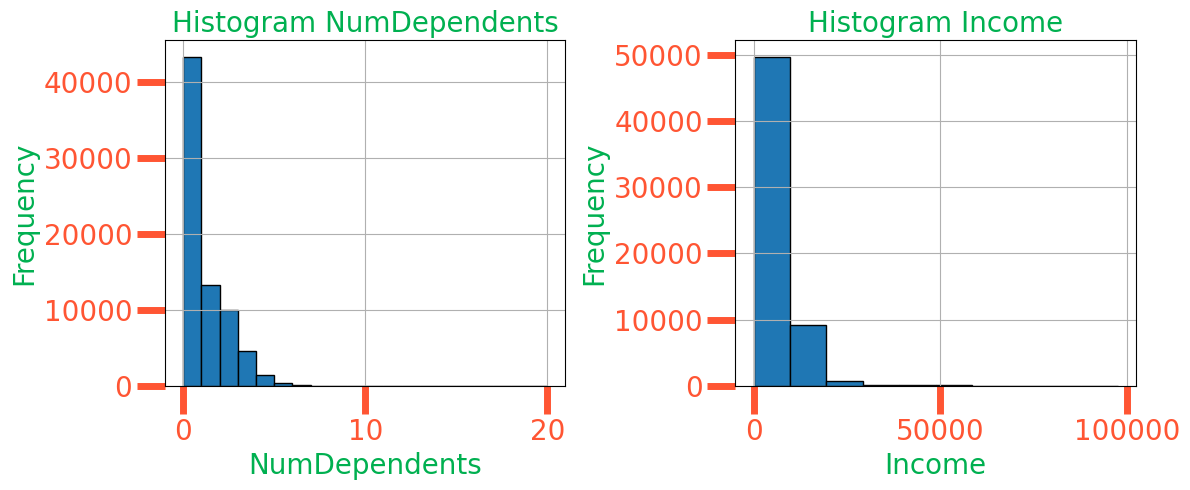

Информация по NumDependents:
MIN: 0.00
Q1: 0.00
Медиана: 0.00
Среднее: 0.76
Стандартное отклонение: 1.11
Q3: 1.00
MAX: 20.00
IQR: 1.00
Границы выбросов: [-1.50, 2.50]
Выбросы слева (< -1.50): 0 штук
Выбросы справа (> 2.50): 6518 штук
Всего выбросов: 6518 штук
Процент выбросов: 8.69%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Информация по Income:
MIN: 0.00
Q1: 3421.35
Медиана: 5424.55
Среднее: 6740.06
Стандартное отклонение: 14228.75
Q3: 8291.52
MAX: 1805573.35
IQR: 4870.16
Границы выбросов: [-3883.89, 15596.76]
Выбросы слева (< -3883.89): 0 штук
Выбросы справа (> 15596.76): 2507 штук
Всего выбросов: 2507 штук
Процент выбросов: 3.34%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ящики с усами для NumDependents и Income от Delinquent90
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Delinquent90', y='NumDependents', data=data, ax=ax1)
ax1.set_title('NumDependents по Delinquent90')

sns.boxplot(x='Delinquent90', y='Income', data=data, ax=ax2)
ax2.set_title('Income по Delinquent90')

plt.tight_layout()
plt.show()

# Простые ящики с усами
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y='NumDependents', data=data, ax=ax1)
ax1.set_title('NumDependents')

sns.boxplot(y='Income', data=data, ax=ax2)
ax2.set_title('Income')

plt.tight_layout()
plt.show()

# Гистограммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

data['NumDependents'].hist(bins=20, edgecolor='black', ax=ax1)
ax1.set_title('Histogram NumDependents')
ax1.set_xlabel('NumDependents')
ax1.set_ylabel('Frequency')

data[data['Income']<100000]['Income'].hist(bins=10, edgecolor='black', ax=ax2)
ax2.set_title('Histogram Income')
ax2.set_xlabel('Income')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Статистика для NumDependents
column = 'NumDependents'
Q1 = data[column].quantile(0.25)
Q3 = data[column].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

out_low = data[data[column] < lower_bound]
out_high = data[data[column] > upper_bound]

print(f"Информация по {column}:")
print(f"MIN: {data[column].min():.2f}")
print(f"Q1: {Q1:.2f}")
print(f"Медиана: {data[column].median():.2f}")
print(f"Среднее: {data[column].mean():.2f}")
print(f"Стандартное отклонение: {data[column].std():.2f}")
print(f"Q3: {Q3:.2f}")
print(f"MAX: {data[column].max():.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Выбросы слева (< {lower_bound:.2f}): {len(out_low)} штук")
print(f"Выбросы справа (> {upper_bound:.2f}): {len(out_high)} штук")
print(f"Всего выбросов: {len(out_low) + len(out_high)} штук")
print(f"Процент выбросов: {(len(out_low) + len(out_high)) / len(data) * 100:.2f}%")
print("-" * 200)

# Статистика для Income
column = 'Income'
Q1 = data[column].quantile(0.25)
Q3 = data[column].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

out_low = data[data[column] < lower_bound]
out_high = data[data[column] > upper_bound]

print(f"Информация по {column}:")
print(f"MIN: {data[column].min():.2f}")
print(f"Q1: {Q1:.2f}")
print(f"Медиана: {data[column].median():.2f}")
print(f"Среднее: {data[column].mean():.2f}")
print(f"Стандартное отклонение: {data[column].std():.2f}")
print(f"Q3: {Q3:.2f}")
print(f"MAX: {data[column].max():.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Выбросы слева (< {lower_bound:.2f}): {len(out_low)} штук")
print(f"Выбросы справа (> {upper_bound:.2f}): {len(out_high)} штук")
print(f"Всего выбросов: {len(out_low) + len(out_high)} штук")
print(f"Процент выбросов: {(len(out_low) + len(out_high)) / len(data) * 100:.2f}%")
print("-" * 200)

Для иждивенцов имеем довольно скошенное распределение, большинство обеспечивает сами себя. По доходам существуют лица из другой лиги, где деньги как будто печатают. Пропуски для иждивенцов заполню по похожим объктам через соседей, а зарплату медианой, так как олигархи сильно сместили среднее.


In [10]:
from sklearn.impute import KNNImputer

# KNN
before = data['NumDependents'].mean()
imputer = KNNImputer(n_neighbors=5)
data['NumDependents'] = imputer.fit_transform(data[['NumDependents']])[:, 0].round()
print(f"Пропусков осталось: {data['NumDependents'].isna().sum()}")
print(f"Среднее до: {before}")
print(f"Среднее после: {data['NumDependents'].mean()}")

Пропусков осталось: 0
Среднее до: 0.755965738054841
Среднее после: 0.7622


In [11]:
before = data['Income'].mean()
data['Income'] = data['Income'].fillna(data['Income'].median())
print(f"Пропусков осталось: {data['Income'].isna().sum()}")
print(f"Среднее до: {before}")
print(f"Среднее после: {data['Income'].mean()}")

Пропусков осталось: 0
Среднее до: 6740.0592870656155
Среднее после: 6479.641558153186


In [12]:
### пропусков больше быть не должно
data.isnull().sum()

,0
DIR,0
Age,0
NumLoans,0
NumRealEstateLoans,0
NumDependents,0
Num30-59Delinquencies,0
Num60-89Delinquencies,0
Income,0
BalanceToCreditLimit,0
Delinquent90,0


## Обработка выбросов

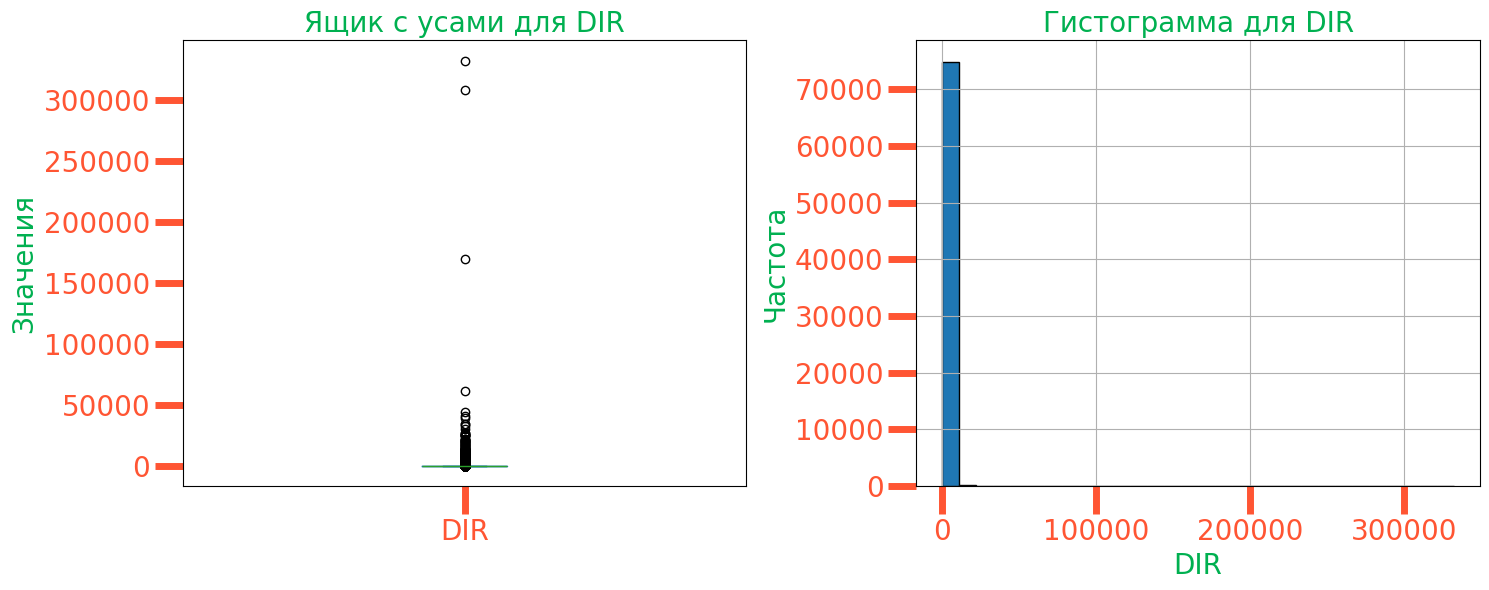

Информация по DIR:
MIN: 0.00
Q1: 0.18
Медиана: 0.37
Среднее: 353.26
Стандартное отклонение: 2117.24
Q3: 0.86
MAX: 332600.27
IQR: 0.69
Границы выбросов: [-0.85, 1.89]
Выбросы слева (< -0.85): 0 штук
Выбросы справа (> 1.89): 15608 штук
Всего выбросов: 15608 штук
Процент выбросов: 20.81%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


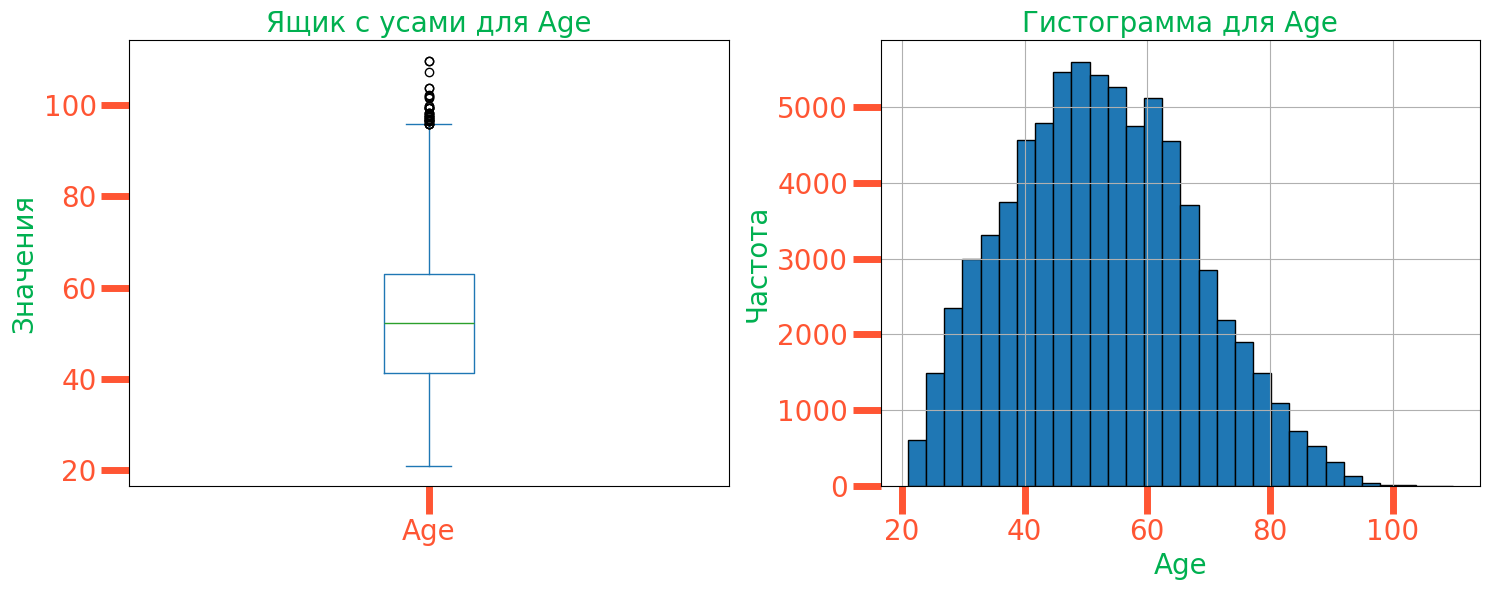

Информация по Age:
MIN: 21.00
Q1: 41.30
Медиана: 52.20
Среднее: 52.60
Стандартное отклонение: 14.87
Q3: 63.10
MAX: 109.80
IQR: 21.80
Границы выбросов: [8.60, 95.80]
Выбросы слева (< 8.60): 0 штук
Выбросы справа (> 95.80): 36 штук
Всего выбросов: 36 штук
Процент выбросов: 0.05%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


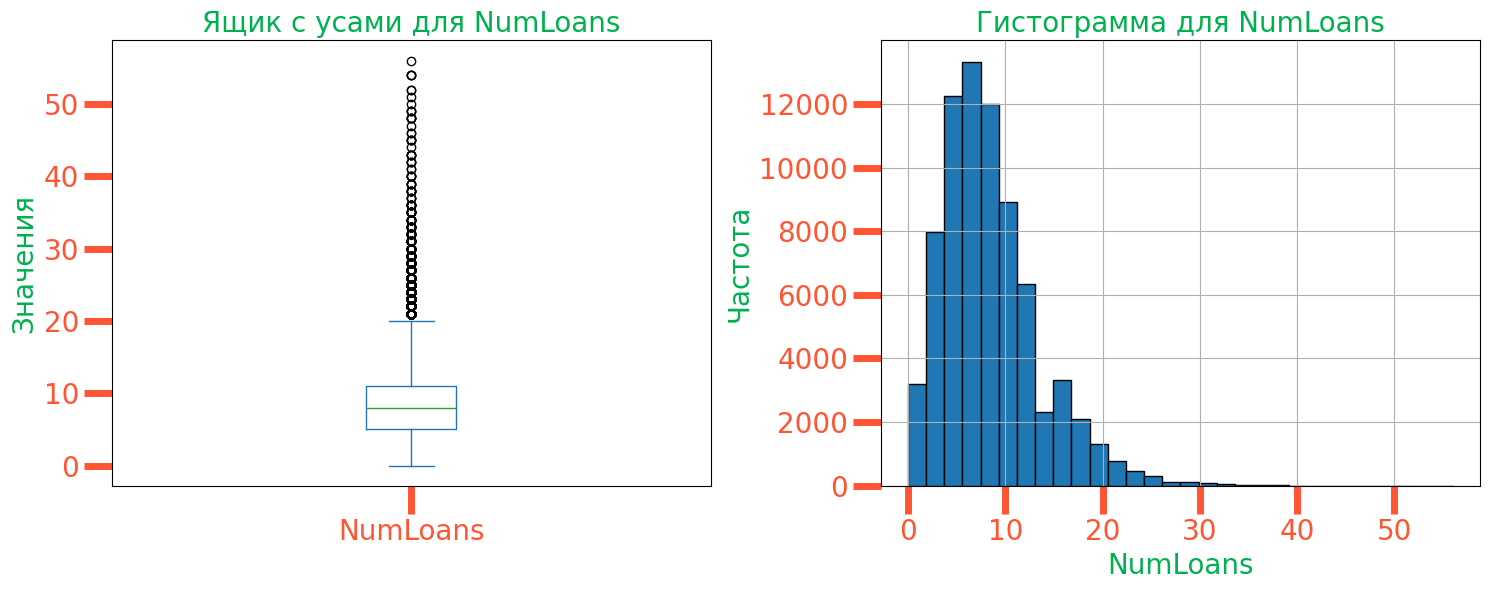

Информация по NumLoans:
MIN: 0.00
Q1: 5.00
Медиана: 8.00
Среднее: 8.45
Стандартное отклонение: 5.16
Q3: 11.00
MAX: 56.00
IQR: 6.00
Границы выбросов: [-4.00, 20.00]
Выбросы слева (< -4.00): 0 штук
Выбросы справа (> 20.00): 2000 штук
Всего выбросов: 2000 штук
Процент выбросов: 2.67%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


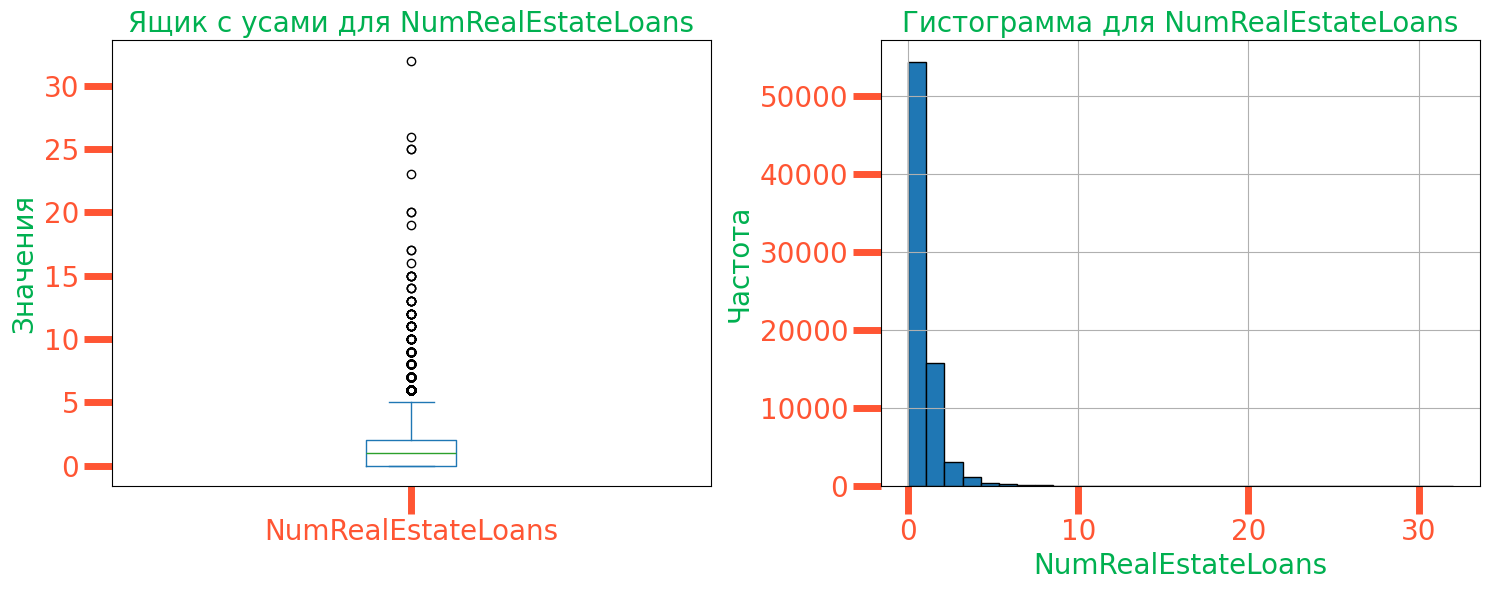

Информация по NumRealEstateLoans:
MIN: 0.00
Q1: 0.00
Медиана: 1.00
Среднее: 1.02
Стандартное отклонение: 1.12
Q3: 2.00
MAX: 32.00
IQR: 2.00
Границы выбросов: [-3.00, 5.00]
Выбросы слева (< -3.00): 0 штук
Выбросы справа (> 5.00): 426 штук
Всего выбросов: 426 штук
Процент выбросов: 0.57%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


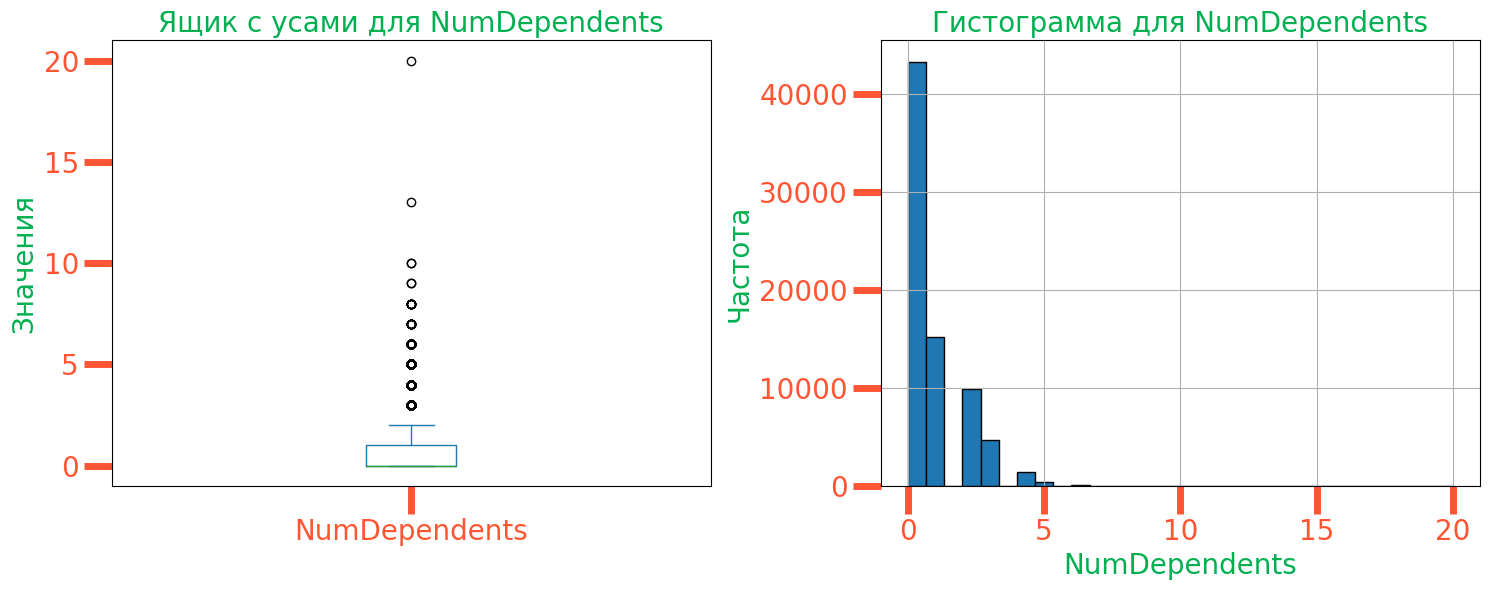

Информация по NumDependents:
MIN: 0.00
Q1: 0.00
Медиана: 0.00
Среднее: 0.76
Стандартное отклонение: 1.09
Q3: 1.00
MAX: 20.00
IQR: 1.00
Границы выбросов: [-1.50, 2.50]
Выбросы слева (< -1.50): 0 штук
Выбросы справа (> 2.50): 6518 штук
Всего выбросов: 6518 штук
Процент выбросов: 8.69%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


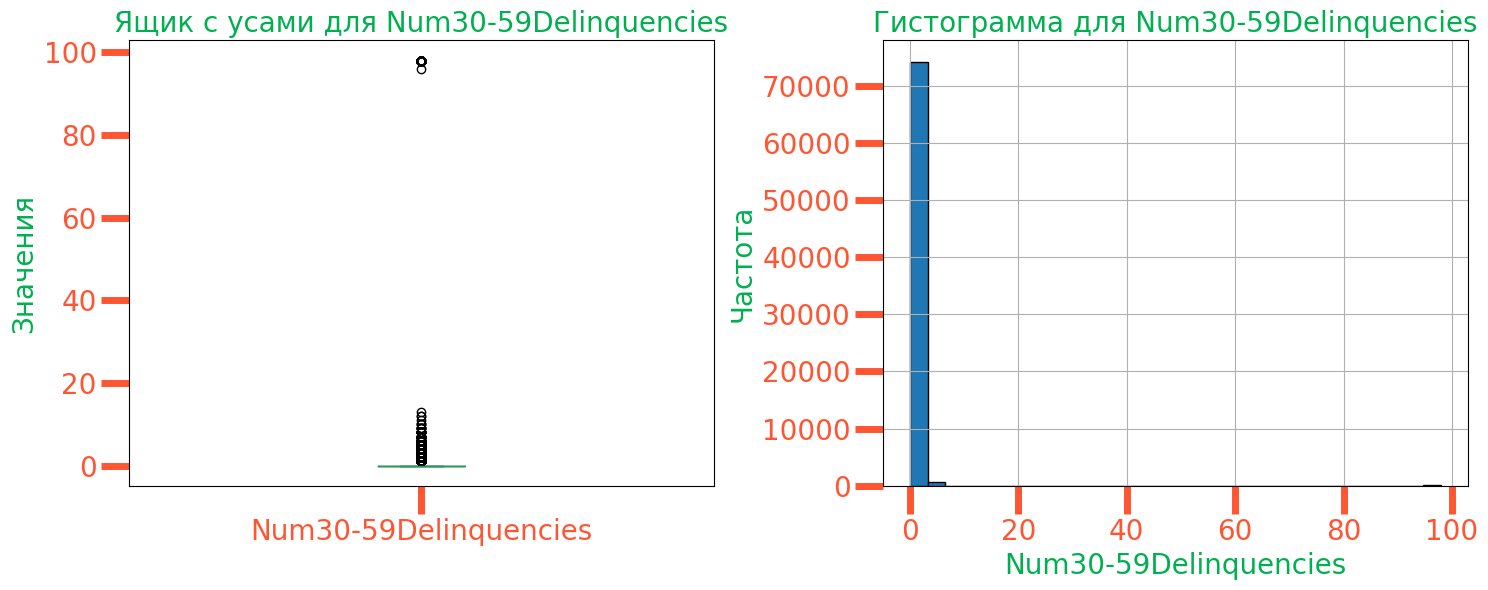

Информация по Num30-59Delinquencies:
MIN: 0.00
Q1: 0.00
Медиана: 0.00
Среднее: 0.43
Стандартное отклонение: 4.28
Q3: 0.00
MAX: 98.00
IQR: 0.00
Границы выбросов: [0.00, 0.00]
Выбросы слева (< 0.00): 0 штук
Выбросы справа (> 0.00): 11988 штук
Всего выбросов: 11988 штук
Процент выбросов: 15.98%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


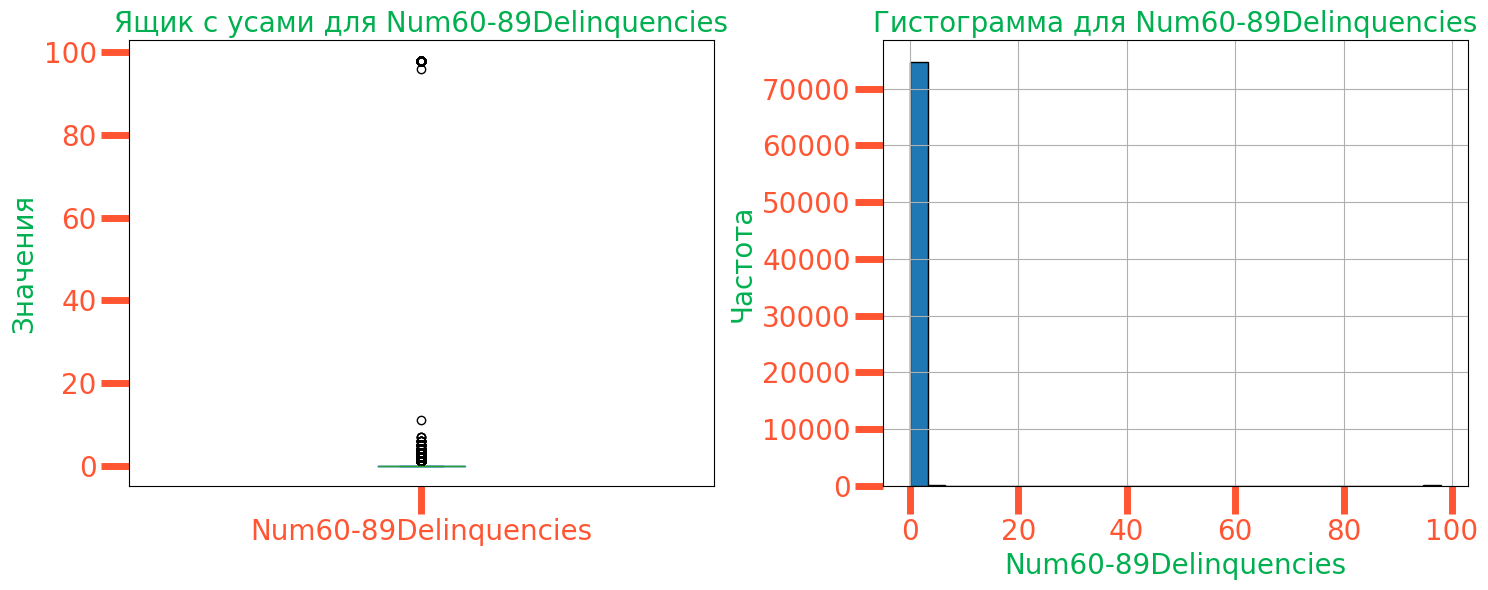

Информация по Num60-89Delinquencies:
MIN: 0.00
Q1: 0.00
Медиана: 0.00
Среднее: 0.25
Стандартное отклонение: 4.24
Q3: 0.00
MAX: 98.00
IQR: 0.00
Границы выбросов: [0.00, 0.00]
Выбросы слева (< 0.00): 0 штук
Выбросы справа (> 0.00): 3839 штук
Всего выбросов: 3839 штук
Процент выбросов: 5.12%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


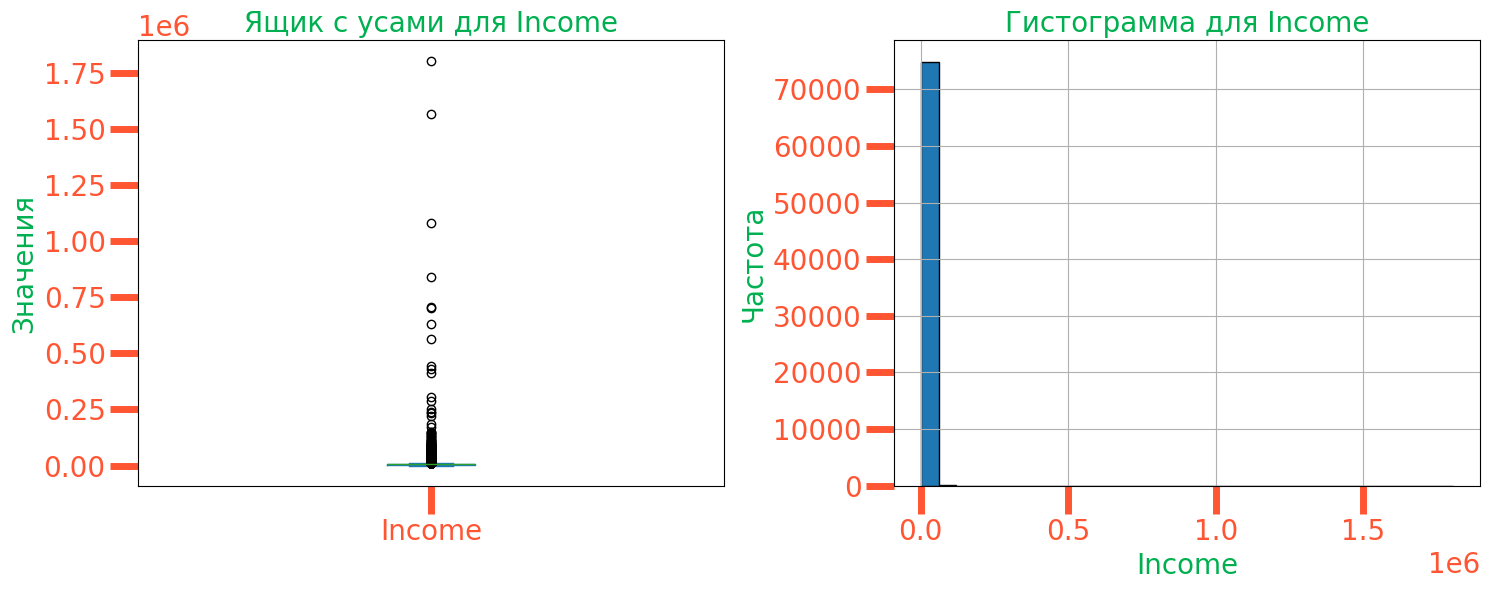

Информация по Income:
MIN: 0.00
Q1: 3948.96
Медиана: 5424.55
Среднее: 6479.64
Стандартное отклонение: 12753.56
Q3: 7406.51
MAX: 1805573.35
IQR: 3457.55
Границы выбросов: [-1237.36, 12592.83]
Выбросы слева (< -1237.36): 0 штук
Выбросы справа (> 12592.83): 4781 штук
Всего выбросов: 4781 штук
Процент выбросов: 6.37%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


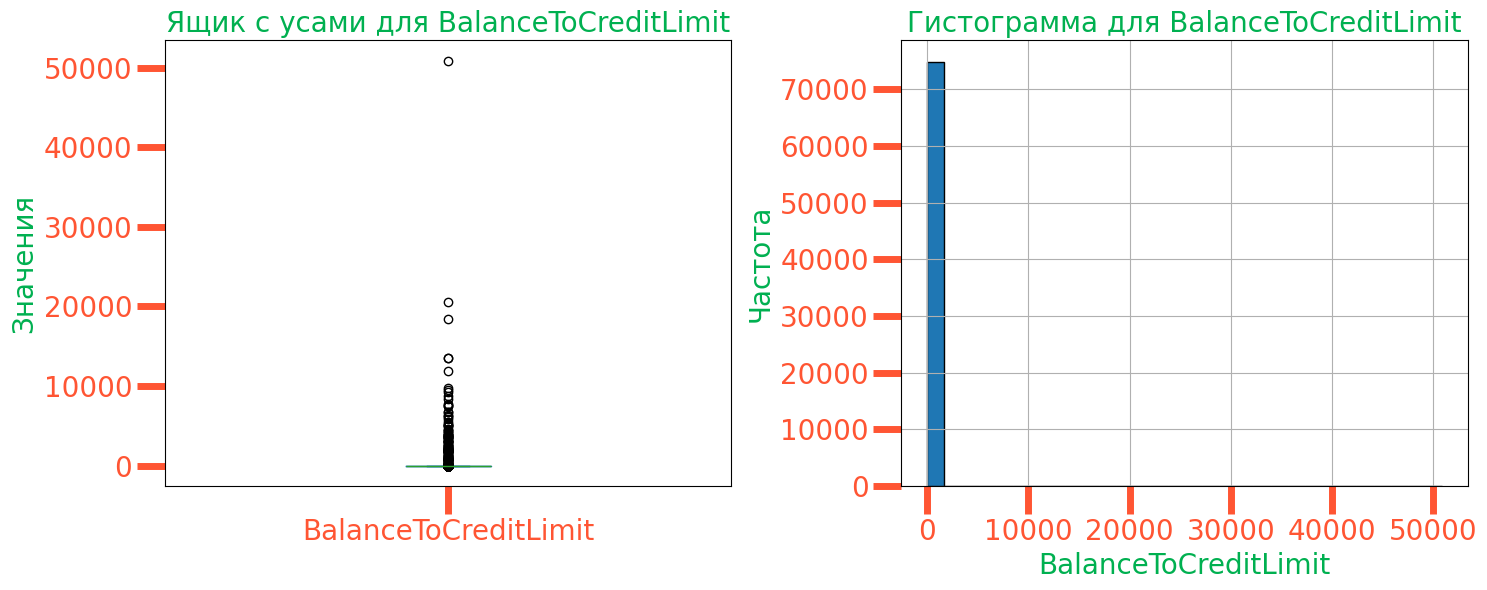

Информация по BalanceToCreditLimit:
MIN: 0.00
Q1: 0.03
Медиана: 0.15
Среднее: 6.28
Стандартное отклонение: 267.74
Q3: 0.56
MAX: 50873.87
IQR: 0.53
Границы выбросов: [-0.77, 1.36]
Выбросы слева (< -0.77): 0 штук
Выбросы справа (> 1.36): 398 штук
Всего выбросов: 398 штук
Процент выбросов: 0.53%
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [13]:
### для числовых колонок построим гистограммы и ящики с усами со всякой статистикой
### отберем числовые колонки
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = data.loc[:, data.dtypes !=object].columns.drop('Delinquent90')

for column in numeric_columns:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

  # Ящик с усами
  data[column].plot(kind='box', ax=ax1)
  ax1.set_title(f'Ящик с усами для {column}')
  ax1.set_ylabel('Значения')

  # Гистограмма
  data[column].hist(bins=30, ax=ax2, edgecolor='black')
  ax2.set_title(f'Гистограмма для {column}')
  ax2.set_xlabel(column)
  ax2.set_ylabel('Частота')

  plt.tight_layout()
  plt.show()

  # Статистика (остается без изменений)
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  out_low = data[data[column] < lower_bound]
  out_high = data[data[column] > upper_bound]

  print(f"Информация по {column}:")
  print(f"MIN: {data[column].min():.2f}")
  print(f"Q1: {Q1:.2f}")
  print(f"Медиана: {data[column].median():.2f}")
  print(f"Среднее: {data[column].mean():.2f}")
  print(f"Стандартное отклонение: {data[column].std():.2f}")
  print(f"Q3: {Q3:.2f}")
  print(f"MAX: {data[column].max():.2f}")
  print(f"IQR: {IQR:.2f}")
  print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
  print(f"Выбросы слева (< {lower_bound:.2f}): {len(out_low)} штук")
  print(f"Выбросы справа (> {upper_bound:.2f}): {len(out_high)} штук")
  print(f"Всего выбросов: {len(out_low) + len(out_high)} штук")
  print(f"Процент выбросов: {(len(out_low) + len(out_high)) / len(data) * 100:.2f}%")
  print("-" * 200)


1. **DIR** - выделяются явные выбросы, как я понял, это отношение долга к доходу, и значение больше 50 000  я уберу, оставлю некоторые выбросы, потому что их много, ведь не могу же пятую часть удалить данных, но аномальные удалю
2. **age** - по возрасту решу удалить все выбросы справа, даже 0,5% думаю лучше удалить, смотря на гистограмму
3. **NumLoans** - выбросов немало, 2.7% от всех данных, это люди с большим количеством кредитов, видимо всякие там айфоны, стиралки посудомойки, машины, квартиры, пылесосы, все, что некрасиво лежит - в кредит. Можно создать категории, как вариант, но я оставлю без именений, думаю, что это важный параметр.
4. **NumRealEstateLoans** - а вот, что касается ипотек и займов в недвижимости, позволю себе удалить, ведь это всего 0.57% данных, минимальная потеря, особенно странно представить 30 ипотек и одного человека, уберем.
5. **NumDependents** - слишком большой объем данных для удаления, но представить больше 8 иждивенцов затруднительно, хотя это чисто интуиция, остановлюс на данном пороге отсечения, особенно 20 строк потерять не страшно.
6. **Num30-59Delinquencies** - ящик с усами не может хорошо охарактеризовать данную фичу, большинство людей не имеют просрочки по платежу, а именно 84% клиентов. Причем 139 клиентов имеют ровно 98 просрочек, один 96, это типа 10 лет каждый месяц просрочка, физически нереалистичная кодировка,удалю их.
7. **Num60-89Delinquencies** - тут аналогичная ситуация, может быть я и ошибусь, удалив данных клиентов, но это очень странно.
8. **income** - 798 абсолютно безработных, больше тысячи богачей, вполне реальная ситуация, наверное. Есть и абсолютные чемпионы. которые деньги печатают. Можно прологарифмировать, но сложно интерпретировать, пока оставлю как есть, но можно вернуться к этому вопросу, если будет плохая модель.
9. **BalanceToCreditLimit** - если я правильно понял, то это отношение суммы денег на кредитке к макс лимиту операции, то есть,например,  на карте 10 млн долларов, а лимит тысяча долларов, то коэффициент будет 10 000, это что-то очень необъяснимое, такое же невозможно в реальности, предположу, что больше 10 это уже какие-то технические сбои.


In [14]:
data[data['Income'] == 0]

,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
client_id,,,,,,,,,,
64,969.154153,22.1,1,0,0.0,0,0,0.0,1.002433,0
104,1346.365592,29.1,8,1,0.0,0,0,0.0,0.000000,0
106,609.086746,77.0,6,0,0.0,0,0,0.0,0.049525,0
124,640.222752,26.1,3,0,0.0,0,0,0.0,1.006795,0
142,0.000000,62.6,1,0,0.0,0,0,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...
73933,4146.747376,41.0,17,2,3.0,0,0,0.0,0.108769,0
73944,1765.092652,52.3,14,2,0.0,0,0,0.0,0.314355,0
74237,1949.062948,51.2,9,2,4.0,1,0,0.0,0.874608,0


In [15]:
len(data[data['Num60-89Delinquencies'] != 0]) / len(data)

0.051186666666666665

In [16]:
### 1. DIR
data = data[data['DIR'] <= 50000]

In [17]:
### 2. age
upper_cutoff = data['Age'].quantile(0.975)
data = data[data['Age'] <= upper_cutoff]

In [18]:
### 3. NumLoans

In [19]:
### 4. NumRealEstateLoans
data = data[data['NumRealEstateLoans'] <= 5]

In [20]:
### 5. NumDependents
data = data[data['NumDependents'] <= 8]

In [21]:
### 6. Num30-59Delinquencies
data = data[data['Num30-59Delinquencies'] <= 90]

In [22]:
### 7. Num60-89Delinquencies
data[data['Num60-89Delinquencies'] >= 10]

,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
client_id,,,,,,,,,,
66772,0.61061,40.2,19,3,0.0,0,11,12108.696957,0.879949,1


In [23]:
### 8. income

In [24]:
### 9. BalanceToCreditLimit
data = data[data['Num30-59Delinquencies'] <= 10]

ЕСЛИ МОДЕЛЬ ПЛОХА!!!
ПОПРОБОВАТЬ СЛЕДУЮЩЕЕ:
1) удалить богачей
2) сократить numloans

## Корреляция

In [25]:
numeric_columns

Index(['DIR', 'Age', 'NumLoans', 'NumRealEstateLoans', 'NumDependents',
       'Num30-59Delinquencies', 'Num60-89Delinquencies', 'Income',
       'BalanceToCreditLimit'],
      dtype='object')

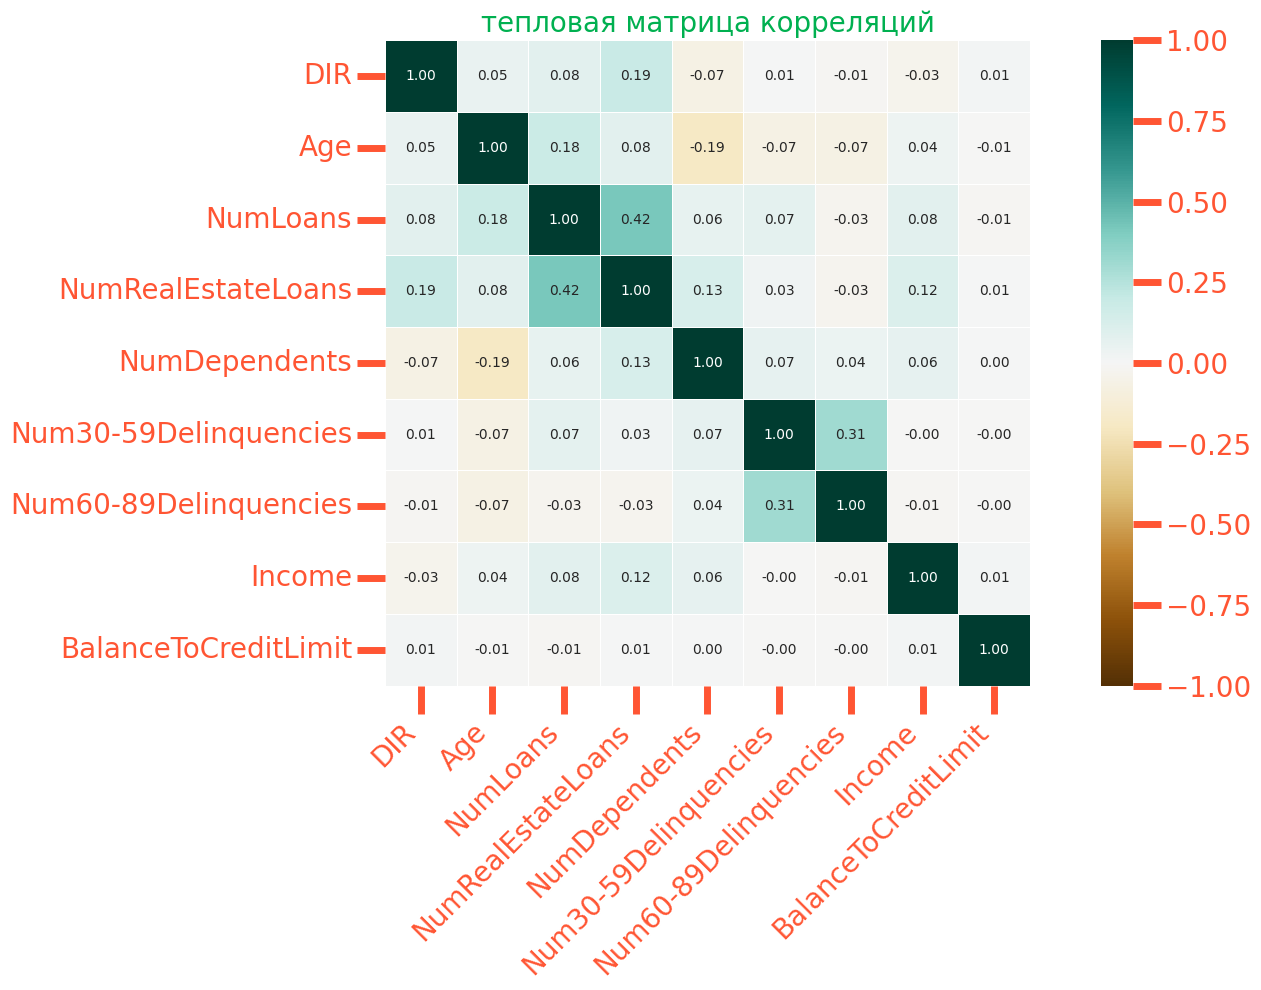

In [26]:
### нарисуем тепловую карту корреляций
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

sns.heatmap(data[numeric_columns].corr(),
            xticklabels=numeric_columns,
            yticklabels=numeric_columns,
            cmap='BrBG',
            vmin=-1,
            vmax=1,
            annot=True,
            fmt='.2f',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('тепловая матрица корреляций')
plt.xticks(rotation=45, ha='right')
plt.yticks()
plt.tight_layout()
plt.show()


In [27]:
### немножко сворую алгоритмы со stackoverflow, выведу топ корреляций

def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(data[numeric_columns], 10))



Top Absolute Correlations
NumLoans               NumRealEstateLoans       0.420402
Num30-59Delinquencies  Num60-89Delinquencies    0.307019
DIR                    NumRealEstateLoans       0.189247
Age                    NumDependents            0.189242
                       NumLoans                 0.181027
NumRealEstateLoans     NumDependents            0.127402
                       Income                   0.116877
Age                    NumRealEstateLoans       0.083618
NumLoans               Income                   0.081135
DIR                    NumLoans                 0.079428
dtype: float64


логические выводы:
1. Число займов.. и число ипотек.. имеют перекрывающую информацию между собой, поэтому между  ними  наибольшая корреляция в датасете
2. Клиенты с просрочками 30-59 дней склонны к просрочкам и в 60-89 дней
3. Чем выше возраст, тем больше кредитов, хех))
4. Чем страше клиент, тем больше иждевенцов

Что бы сделал:
1. объединить колонки с просрочками каким-то образом  с выделением категорий
2. остальное, думаю не критично с учетом, что мы будем строить дерево решений

## ОБУЧЕНИЕ

In [28]:
X = data.drop('Delinquent90', axis=1)
y = data['Delinquent90']

Delinquent90
0    67746
1     4817
Name: count, dtype: int64
Просрочили через 90 дней: 6.6%


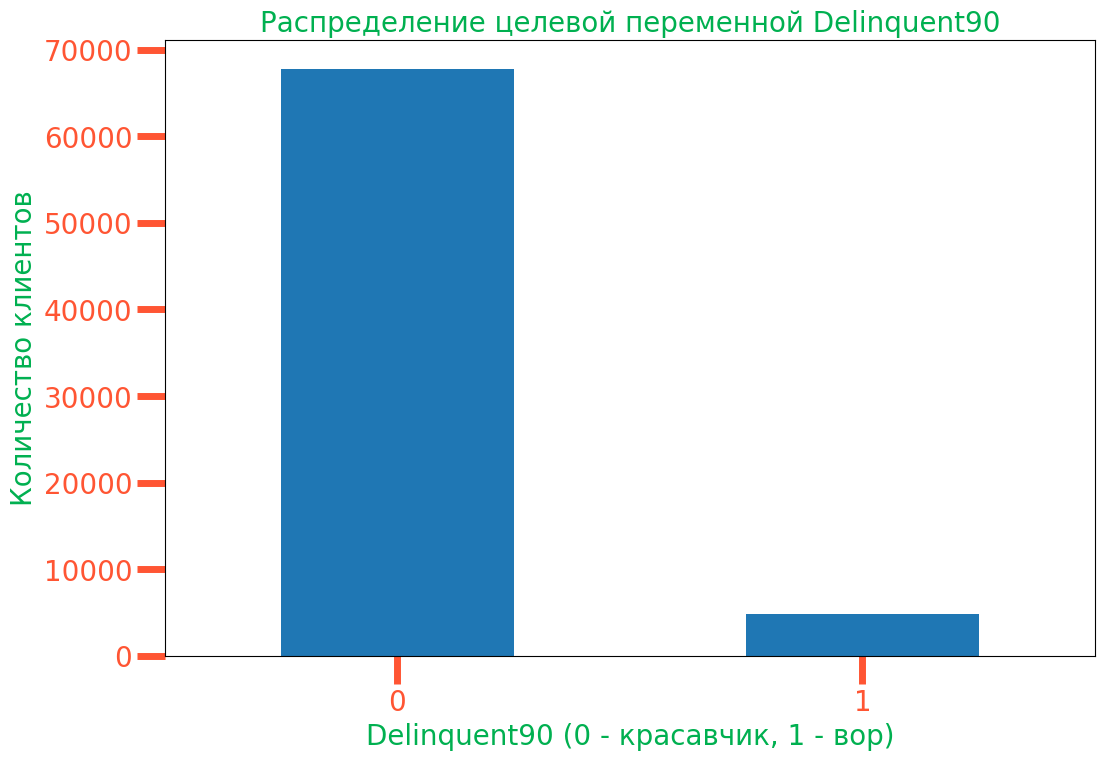

In [29]:
# Распределение таргета
target_counts = data['Delinquent90'].value_counts()
print(target_counts)
print(f"Просрочили через 90 дней: {target_counts[1]/len(data)*100:.1f}%")

plt.figure(figsize=(12, 8))
data['Delinquent90'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной Delinquent90')
plt.xlabel('Delinquent90 (0 - красавчик, 1 - вор)')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.show()

## РЕШАЮЩЕЕ ДЕРЕВО

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.2,
                                                   shuffle=True,
                                                   random_state=2022)

БАЛАНС ОГРОМНЫЙ 93% против 7%

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.2,
                                                   shuffle=True,
                                                   random_state=2022)

# Pipeline с обработкой несбалансированности
pipe_1 = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=2022)),
    ("decision_tree", DecisionTreeClassifier(random_state=2022))
])

# Обучение
pipe_1.fit(X_train, y_train)

# Предсказания
y_pred = pipe_1.predict(X_test)
y_pred_proba = pipe_1.predict_proba(X_test)[:, 1]

# Оценка качества
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


Confusion Matrix:
[[11732  1829]
 [  602   350]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     13561
           1       0.16      0.37      0.22       952

    accuracy                           0.83     14513
   macro avg       0.56      0.62      0.56     14513
weighted avg       0.90      0.83      0.86     14513

ROC-AUC: 0.6164


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_1 = {
    "decision_tree__max_depth": [1,2,3,4,5,6,7,8,9,10,11]
}

search_1 = GridSearchCV(pipe_1, param_grid_1, cv=5, scoring='roc_auc', verbose=1)
search_1.fit(X_train, y_train)

print(f"Best parameter (CV score={search_1.best_score_:.5f}):")
print(search_1.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search_1.score(X_test, y_test):.5f}")

# Анализ результатов для всех глубин
results = search_1.cv_results_
print("\nРезультаты для всех глубин:")
for i, depth in enumerate(param_grid_1['decision_tree__max_depth']):
    mean_score = results['mean_test_score'][i]
    std_score = results['std_test_score'][i]
    print(f"max_depth={depth}: ROC-AUC = {mean_score:.5f} (±{std_score:.5f})")

# Предсказания лучшей модели
y_pred_best = search_1.predict(X_test)
y_pred_proba_best = search_1.predict_proba(X_test)[:, 1]

print("Classification Report для лучшей модели:")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best parameter (CV score=0.81171):
{'decision_tree__max_depth': 6}
Качество лучшей модели на финальном тесте: 0.81905

Результаты для всех глубин:
max_depth=1: ROC-AUC = 0.71532 (±0.00532)
max_depth=2: ROC-AUC = 0.77092 (±0.00794)
max_depth=3: ROC-AUC = 0.79461 (±0.00463)
max_depth=4: ROC-AUC = 0.80801 (±0.00286)
max_depth=5: ROC-AUC = 0.81000 (±0.00495)
max_depth=6: ROC-AUC = 0.81171 (±0.00504)
max_depth=7: ROC-AUC = 0.80565 (±0.00571)
max_depth=8: ROC-AUC = 0.79466 (±0.00563)
max_depth=9: ROC-AUC = 0.78278 (±0.00593)
max_depth=10: ROC-AUC = 0.76645 (±0.00654)
max_depth=11: ROC-AUC = 0.75037 (±0.00612)
Classification Report для лучшей модели:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     13211
           1       0.19      0.68      0.29       932

    accuracy                           0.78     14143
   macro avg       0.58      0.74      0.58     14143
weighted avg   

**Промежуточный вывод**
1. оптимальный параметр глубины решающего дерева равен 6, при данном значении получена наивысшая auc-roc оценка
2. при 7-11 начинается пдаение качества на тесте из-за переобучения модели на кросс-валидации, так как модель начинает запоминать шум и и конкретные закономерности из тренировочных данных. Потеря обобщающей способности.

In [35]:
from sklearn.model_selection import GridSearchCV
param_grid_2 = {
    "decision_tree__max_depth": [ 7],
    "decision_tree__min_samples_split": [2],
    "decision_tree__min_impurity_decrease": [0],
    "decision_tree__max_leaf_nodes": [50]
}

search_2 = GridSearchCV(pipe_1, param_grid_2, cv=5, scoring='roc_auc', verbose=1)
search_2.fit(X_train, y_train)

print(f"Best parameter (CV score={search_2.best_score_:.5f}):")
print(search_2.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search_2.score(X_test, y_test):.5f}")
# Предсказания лучшей модели
y_pred_best = search_2.predict(X_test)
y_pred_proba_best = search_2.predict_proba(X_test)[:, 1]

print("Classification Report для лучшей модели:")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameter (CV score=0.81913):
{'decision_tree__max_depth': 7, 'decision_tree__max_leaf_nodes': 50, 'decision_tree__min_impurity_decrease': 0, 'decision_tree__min_samples_split': 2}
Качество лучшей модели на финальном тесте: 0.82179
Classification Report для лучшей модели:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     13561
           1       0.17      0.77      0.28       952

    accuracy                           0.74     14513
   macro avg       0.57      0.75      0.56     14513
weighted avg       0.93      0.74      0.80     14513

ROC-AUC: 0.8218


На решающих деревьях смогли добиться на тесте значения = 0.826

## АНСАМБЛЕВЫЕ МЕТОДЫ

### Бэггинг

Мне пришлось убрать метод опорных векторов из рассмотрения класс. моделей, ноутбук не выдерживал обучения и ломался, а времени у меня не осталось почти

In [ ]:
# 1. Pipeline с бэггингом
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe_bagging = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=2022)),
    ("bagging", BaggingClassifier(
        estimator=LogisticRegression(random_state=2022),
        random_state=2022
    ))
])

pipe_bagging.fit(X_train, y_train)
y_pred_bagging = pipe_bagging.predict(X_test)
print("Bagging с LogisticRegression:")
print(classification_report(y_test, y_pred_bagging))
print(f"ROC-AUC: {roc_auc_score(y_test, pipe_bagging.predict_proba(X_test)[:, 1]):.4f}")

Bagging с LogisticRegression:
              precision    recall  f1-score   support

           0       0.97      0.80      0.87     13561
           1       0.18      0.63      0.28       952

    accuracy                           0.79     14513
   macro avg       0.57      0.71      0.58     14513
weighted avg       0.92      0.79      0.84     14513

ROC-AUC: 0.7748


In [ ]:
# 2. GridSearchCV для бэггинга
param_grid_bagging = {
    "bagging__n_estimators": [10, 50, 100],
    "bagging__max_samples": [0.5, 0.7, 1.0],
    "bagging__max_features": [0.5, 0.7, 1.0],
    "bagging__estimator__C": [0.1, 1, 10]  # параметр базовой модели
}

search_bagging = GridSearchCV(
    pipe_bagging,
    param_grid_bagging,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

search_bagging.fit(X_train, y_train)

print(f"Best parameters (CV score={search_bagging.best_score_:.5f}):")
print(search_bagging.best_params_)
print(f"Качество на тесте: {search_bagging.score(X_test, y_test):.5f}")

# Отчет для лучшей модели
y_pred_best_bagging = search_bagging.predict(X_test)
print("\nClassification Report для лучшей бэггинг модели:")
print(classification_report(y_test, y_pred_best_bagging))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters (CV score=0.78033):
{'bagging__estimator__C': 0.1, 'bagging__max_features': 1.0, 'bagging__max_samples': 0.5, 'bagging__n_estimators': 50}
Качество на тесте: 0.77653

Classification Report для лучшей бэггинг модели:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     13211
           1       0.18      0.63      0.29       932

    accuracy                           0.79     14143
   macro avg       0.58      0.72      0.58     14143
weighted avg       0.92      0.79      0.84     14143



### СТЕКИНГ

In [ ]:
# 1. Pipeline со стекингом
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

estimators = [
    ('lr', LogisticRegression(random_state=2022)),
    ('nb', GaussianNB())
]

pipe_stacking = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=2022)),
    ("stacking", StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(random_state=2022),
        cv=5
    ))
])

pipe_stacking.fit(X_train, y_train)
y_pred_stacking = pipe_stacking.predict(X_test)
print("Stacking с классическими моделями:")
print(classification_report(y_test, y_pred_stacking))
print(f"ROC-AUC: {roc_auc_score(y_test, pipe_stacking.predict_proba(X_test)[:, 1]):.4f}")

Stacking с классическими моделями:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     13561
           1       0.18      0.62      0.28       952

    accuracy                           0.79     14513
   macro avg       0.58      0.71      0.58     14513
weighted avg       0.92      0.79      0.84     14513

ROC-AUC: 0.7747


In [ ]:
# 2. GridSearchCV для стекинга
param_grid_stacking = {
    "stacking__final_estimator__C": [0.1, 1, 10],
    "stacking__passthrough": [True, False],
    "stacking__stack_method": ['predict_proba', 'auto']
}

search_stacking = GridSearchCV(
    pipe_stacking,
    param_grid_stacking,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

search_stacking.fit(X_train, y_train)

print(f"Best parameters (CV score={search_stacking.best_score_:.5f}):")
print(search_stacking.best_params_)
print(f"Качество на тесте: {search_stacking.score(X_test, y_test):.5f}")

# Отчет для лучшей модели
y_pred_best_stacking = search_stacking.predict(X_test)
print("\nClassification Report для лучшей стекинг модели:")
print(classification_report(y_test, y_pred_best_stacking))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters (CV score=0.78498):
{'stacking__final_estimator__C': 10, 'stacking__passthrough': True, 'stacking__stack_method': 'predict_proba'}
Качество на тесте: 0.77610

Classification Report для лучшей стекинг модели:
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     13561
           1       0.18      0.62      0.28       952

    accuracy                           0.79     14513
   macro avg       0.58      0.71      0.58     14513
weighted avg       0.92      0.79      0.84     14513



### Случайный лес

In [ ]:
# 1. Pipeline со случайным лесом
from sklearn.ensemble import RandomForestClassifier

pipe_rf = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=2022)),
    ("rf", RandomForestClassifier(random_state=2022))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, pipe_rf.predict_proba(X_test)[:, 1]):.4f}")

Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     13561
           1       0.26      0.41      0.32       952

    accuracy                           0.88     14513
   macro avg       0.61      0.67      0.63     14513
weighted avg       0.91      0.88      0.90     14513

ROC-AUC: 0.7945


In [ ]:
# 2. GridSearchCV для случайного леса
param_grid_rf = {
    "rf__n_estimators": [50, 100],
    "rf__max_depth": [6, 10],
    "rf__min_samples_split": [5, 10],
    "rf__min_samples_leaf": [1, 4],
    "rf__max_features": ['sqrt', 'log2']
}

search_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

search_rf.fit(X_train, y_train)

print(f"Best parameters (CV score={search_rf.best_score_:.5f}):")
print(search_rf.best_params_)
print(f"Качество на тесте: {search_rf.score(X_test, y_test):.5f}")

# Отчет для лучшей модели
y_pred_best_rf = search_rf.predict(X_test)
print("\nClassification Report для лучшей Random Forest модели:")
print(classification_report(y_test, y_pred_best_rf))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters (CV score=0.83267):
{'rf__max_depth': 6, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Качество на тесте: 0.83554

Classification Report для лучшей Random Forest модели:
              precision    recall  f1-score   support

           0       0.98      0.75      0.85     13561
           1       0.18      0.78      0.29       952

    accuracy                           0.75     14513
   macro avg       0.58      0.76      0.57     14513
weighted avg       0.93      0.75      0.81     14513



### XGBOOST

In [ ]:
# 1. Pipeline с XGBoost
from xgboost import XGBClassifier

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=2022)),
    ("xgb", XGBClassifier(random_state=2022, eval_metric='logloss'))
])

pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, pipe_xgb.predict_proba(X_test)[:, 1]):.4f}")

XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     13561
           1       0.25      0.36      0.29       952

    accuracy                           0.89     14513
   macro avg       0.60      0.64      0.62     14513
weighted avg       0.91      0.89      0.90     14513

ROC-AUC: 0.7910


In [ ]:
# 2. GridSearchCV для XGBoost
param_grid_xgb = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.1, 0.3]
}

search_xgb = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)

print(f"Best parameters (CV score={search_xgb.best_score_:.5f}):")
print(search_xgb.best_params_)
print(f"Качество на тесте: {search_xgb.score(X_test, y_test):.5f}")

# Отчет для лучшей модели
y_pred_best_xgb = search_xgb.predict(X_test)
print("\nClassification Report для лучшей XGBoost модели:")
print(classification_report(y_test, y_pred_best_xgb))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters (CV score=0.81375):
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 50}
Качество на тесте: 0.81803

Classification Report для лучшей XGBoost модели:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     13561
           1       0.24      0.52      0.33       952

    accuracy                           0.86     14513
   macro avg       0.60      0.70      0.62     14513
weighted avg       0.92      0.86      0.88     14513



In [ ]:
# 3. F-test для важности признаков
from sklearn.feature_selection import f_classif

# Вычисляем F-test scores
f_scores, p_values = f_classif(X_train, y_train)

# Создаем DataFrame с результатами
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

print("Топ-10 признаков по F-test:")
print(feature_importance.head(10))

# Сравним с важностью признаков из XGBoost
best_xgb = search_xgb.best_estimator_.named_steps['xgb']
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'XGB_Importance': best_xgb.feature_importances_
}).sort_values('XGB_Importance', ascending=False)

print("\nТоп-10 признаков по XGBoost:")
print(xgb_importance.head(10))

Топ-10 признаков по F-test:
                 Feature      F_Score        P_Value
6  Num60-89Delinquencies  4725.971333   0.000000e+00
5  Num30-59Delinquencies  4633.616986   0.000000e+00
1                    Age   753.822455  6.742328e-165
4          NumDependents   117.741403   2.098815e-27
2               NumLoans    66.421858   3.712315e-16
3     NumRealEstateLoans    53.602782   2.485793e-13
7                 Income    34.235072   4.910212e-09
0                    DIR     5.938399   1.481746e-02
8   BalanceToCreditLimit     0.238680   6.251629e-01

Топ-10 признаков по XGBoost:
                 Feature  XGB_Importance
8   BalanceToCreditLimit        0.477342
4          NumDependents        0.232666
3     NumRealEstateLoans        0.084117
5  Num30-59Delinquencies        0.071577
6  Num60-89Delinquencies        0.042890
1                    Age        0.029293
0                    DIR        0.027153
2               NumLoans        0.017915
7                 Income        0.017046


In [36]:
### немножко смухлюю, надо было записывать в переменные результаты, чтобы дф сделать сравнительный, но сейчас совсем лень, сделал по простому)

results = {
    'Model': ['Decision Tree', 'Bagging', 'Stacking', 'Random Forest', 'XGBoost'],
    'CV_Score': [0.81913, 0.78033, 0.78498, 0.83267, 0.81375],
    'Test_Score': [0.82179, 0.77653, 0.77610, 0.83554, 0.81803],
    'Precision_0': [0.98, 0.97, 0.97, 0.98, 0.96],
    'Recall_0': [0.74, 0.80, 0.81, 0.75, 0.88],
    'F1_0': [0.84, 0.88, 0.88, 0.85, 0.92],
    'Precision_1': [0.17, 0.18, 0.18, 0.18, 0.24],
    'Recall_1': [0.77, 0.63, 0.62, 0.78, 0.52],
    'F1_1': [0.28, 0.29, 0.28, 0.29, 0.33],
    'Accuracy': [0.74, 0.79, 0.79, 0.75, 0.86],
    'Macro_Avg_F1': [0.56, 0.58, 0.58, 0.57, 0.62],
    'Weighted_Avg_F1': [0.80, 0.84, 0.84, 0.81, 0.88]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Добавим разницу между тестом и CV для анализа переобучения
results_df['Test_CV_Diff'] = results_df['Test_Score'] - results_df['CV_Score']

print("Сравнение моделей:")
print(results_df.to_string(index=False))

print("\nЛучшие модели по метрикам:")
print(f"Лучший CV Score: {results_df.loc[results_df['CV_Score'].idxmax(), 'Model']} ({results_df['CV_Score'].max():.4f})")
print(f"Лучший Test Score: {results_df.loc[results_df['Test_Score'].idxmax(), 'Model']} ({results_df['Test_Score'].max():.4f})")
print(f"Лучшая Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"Лучший F1 для класса 1: {results_df.loc[results_df['F1_1'].idxmax(), 'Model']} ({results_df['F1_1'].max():.4f})")

Сравнение моделей:
        Model  CV_Score  Test_Score  Precision_0  Recall_0  F1_0  Precision_1  Recall_1  F1_1  Accuracy  Macro_Avg_F1  Weighted_Avg_F1  Test_CV_Diff
Decision Tree    0.8191      0.8218         0.98      0.74  0.84         0.17      0.77  0.28      0.74          0.56             0.80        0.0027
      Bagging    0.7803      0.7765         0.97      0.80  0.88         0.18      0.63  0.29      0.79          0.58             0.84       -0.0038
     Stacking    0.7850      0.7761         0.97      0.81  0.88         0.18      0.62  0.28      0.79          0.58             0.84       -0.0089
Random Forest    0.8327      0.8355         0.98      0.75  0.85         0.18      0.78  0.29      0.75          0.57             0.81        0.0028
      XGBoost    0.8138      0.8180         0.96      0.88  0.92         0.24      0.52  0.33      0.86          0.62             0.88        0.0042

Лучшие модели по метрикам:
Лучший CV Score: Random Forest (0.8327)
Лучший Test Score: 

ВЫВОД: лучше всего справились леса и xgboost, но эти модели все равно далеки от идеала, не могу сказать, что подобрал самые оптимальные параметры. Леса находят почти 80% всех дефолтов, но из-за низкого precision происходит очень много ложных срабатываний. В принципе, если для бизнес задачи важнее не попасться на удочку, то это подойдет, но очень многие добрые клиенты уйдут в небытие, поэтому надо подстраиваться под определенные задачи и цели, ведь терять такой большой доход из-за ложносрабатываемой модели это очень плохо, на мой взгляд.